# Agentic AI Fundamentals

## Notebook 05: Building a Reusable Agent Loop

The previous notebook completed one function-calling cycle manually. A reusable agent must continue operating when the model requests additional tools, handle several calls in one turn, stop when a final answer appears, and terminate safely when the run exceeds its budget.

This notebook turns that procedure into a compact agent runtime. The implementation remains explicit rather than relying on an agent framework, so every model call, tool execution, observation, and stop condition stays visible.

## Learning objectives

By the end of this notebook, you will be able to:

- implement the observe–decide–act cycle as a bounded loop;
- distinguish a final model answer from a function-call response;
- execute multiple tool calls returned in the same turn;
- return validation and runtime failures to the model as observations;
- record a structured execution trace; and
- terminate on completion, configuration errors, or a maximum-step limit.

Everything remains inside this Colab notebook. The repeated setup is intentional: each chapter can be opened and run independently.

## 1. Install dependencies and load the API key

Add `GEMINI_API_KEY` through the key icon in Colab's left sidebar. Do not place the key directly in a notebook that may be published.

In [1]:
%pip install -q -U "google-genai>=1.0.0" "pydantic>=2.7,<3"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 262.5/262.5 kB 10.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.49.0, but you have google-auth 2.58.1 which is incompatible.


In [2]:
import os


def load_gemini_api_key() -> str:
    try:
        from google.colab import userdata

        api_key = userdata.get("GEMINI_API_KEY")
    except (ImportError, KeyError):
        api_key = os.getenv("GEMINI_API_KEY")

    if not api_key:
        raise RuntimeError(
            "Add GEMINI_API_KEY to Colab Secrets or set it as an environment variable."
        )

    return api_key


GEMINI_API_KEY = load_gemini_api_key()
print("API key loaded.")

API key loaded.


## 2. Imports and configuration

`MODEL_NAME` is kept in one place because available model names can change. Replace it with a current Gemini model supporting function calling if necessary.

In [3]:
import json
import re
from dataclasses import dataclass, field
from typing import Any, Callable

from pydantic import (
    BaseModel,
    ConfigDict,
    Field,
    ValidationError,
    field_validator,
)


MODEL_NAME = "gemini-3.8-flash"
print("Configured model:", MODEL_NAME)

Configured model: gemini-3.8-flash


In [4]:
from google import genai


client = genai.Client(api_key=GEMINI_API_KEY)
print("Gemini client initialized.")

Gemini client initialized.


## 3. Define the agent's capabilities

The action space contains multiplication, division, and local note retrieval. Division includes a domain rule that rejects a zero denominator before Python attempts the operation.

In [5]:
def multiply(first_number: float, second_number: float) -> float:
    return first_number * second_number


def divide(numerator: float, denominator: float) -> float:
    return numerator / denominator


COURSE_NOTES = {
    "agent": (
        "An agent places model-driven decisions inside a controlled loop "
        "with tools, state, and stop conditions."
    ),
    "tool": (
        "A tool is an application capability exposed through a validated "
        "and governed interface."
    ),
    "observation": (
        "A tool result becomes an observation that can influence the next "
        "model decision."
    ),
    "trace": (
        "An execution trace records model calls, requested actions, tool "
        "results, failures, and termination reasons."
    ),
}


def search_course_notes(query: str, max_results: int = 2) -> list[dict[str, str]]:
    query_tokens = set(re.findall(r"[a-z0-9]+", query.casefold()))
    matches = []

    for topic, text in COURSE_NOTES.items():
        note_tokens = set(re.findall(r"[a-z0-9]+", f"{topic} {text}".casefold()))
        score = len(query_tokens & note_tokens)

        if score:
            matches.append((score, topic, text))

    matches.sort(reverse=True)

    return [
        {"topic": topic, "text": text}
        for _, topic, text in matches[:max_results]
    ]

In [6]:
class MultiplyArguments(BaseModel):
    model_config = ConfigDict(extra="forbid")

    first_number: float
    second_number: float


class DivideArguments(BaseModel):
    model_config = ConfigDict(extra="forbid")

    numerator: float
    denominator: float

    @field_validator("denominator")
    @classmethod
    def denominator_cannot_be_zero(cls, value: float) -> float:
        if value == 0:
            raise ValueError("denominator must not be zero")
        return value


class SearchArguments(BaseModel):
    model_config = ConfigDict(extra="forbid")

    query: str = Field(min_length=3, max_length=300)
    max_results: int = Field(default=2, ge=1, le=3)

## 4. Build the tool registry

The registry validates every function request locally. Its output is always a structured observation, including failures. This gives the model useful feedback without granting it access to raw Python exceptions or arbitrary functions.

In [7]:
@dataclass(frozen=True)
class Tool:
    name: str
    description: str
    arguments_model: type[BaseModel]
    function: Callable[..., Any]

    def execute(self, arguments: dict[str, Any]) -> Any:
        validated = self.arguments_model.model_validate(arguments)
        return self.function(**validated.model_dump())

    def as_gemini_schema(self) -> dict[str, Any]:
        return {
            "type": "function",
            "name": self.name,
            "description": self.description,
            "parameters": self.arguments_model.model_json_schema(),
        }


class ToolRegistry:
    def __init__(self, tools: list[Tool]) -> None:
        self._tools: dict[str, Tool] = {}

        for tool in tools:
            if tool.name in self._tools:
                raise ValueError(f"Duplicate tool name: {tool.name}")
            self._tools[tool.name] = tool

    def schemas(self) -> list[dict[str, Any]]:
        return [tool.as_gemini_schema() for tool in self._tools.values()]

    def execute(self, name: str, arguments: dict[str, Any]) -> dict[str, Any]:
        tool = self._tools.get(name)

        if tool is None:
            return {
                "success": False,
                "error_type": "unknown_tool",
                "error": f"Tool is not registered: {name}",
            }

        try:
            result = tool.execute(arguments)
        except ValidationError as error:
            return {
                "success": False,
                "error_type": "invalid_arguments",
                "error": error.errors(),
            }
        except Exception as error:
            return {
                "success": False,
                "error_type": "execution_error",
                "error": f"{type(error).__name__}: {error}",
            }

        return {"success": True, "result": result}

In [8]:
registry = ToolRegistry(
    [
        Tool(
            "multiply",
            "Multiply two numbers when an exact product is required.",
            MultiplyArguments,
            multiply,
        ),
        Tool(
            "divide",
            "Divide a numerator by a non-zero denominator.",
            DivideArguments,
            divide,
        ),
        Tool(
            "search_course_notes",
            (
                "Search the local Agentic AI notes for course-specific "
                "definitions not already present in the conversation."
            ),
            SearchArguments,
            search_course_notes,
        ),
    ]
)

gemini_tools = registry.schemas()
print("Tools:", [tool["name"] for tool in gemini_tools])

Tools: ['multiply', 'divide', 'search_course_notes']


## 5. Define a result object and trace

Returning a structured run result is more useful than returning only text. Callers need to know whether the agent completed normally, why it stopped, how many model turns it used, and which actions occurred.

In [9]:
@dataclass
class AgentRun:
    status: str
    answer: str | None
    model_turns: int
    trace: list[dict[str, Any]] = field(default_factory=list)
    stop_reason: str | None = None


def print_trace(run: AgentRun) -> None:
    print(f"Status      : {run.status}")
    print(f"Model turns : {run.model_turns}")
    print(f"Stop reason : {run.stop_reason}")
    print(f"Answer      : {run.answer}")
    print()
    print("Trace:")

    for index, event in enumerate(run.trace, start=1):
        print(f"{index:02d}. {event}")

## 6. Implement the bounded agent loop

Each loop iteration corresponds to one model turn. If Gemini returns no function calls, its textual output is treated as the final answer. If it returns one or more calls, every call is validated and executed, and their results are submitted together in the next interaction.

The previous interaction ID carries the model-side history forward. The trace is maintained independently by our application for debugging and evaluation.

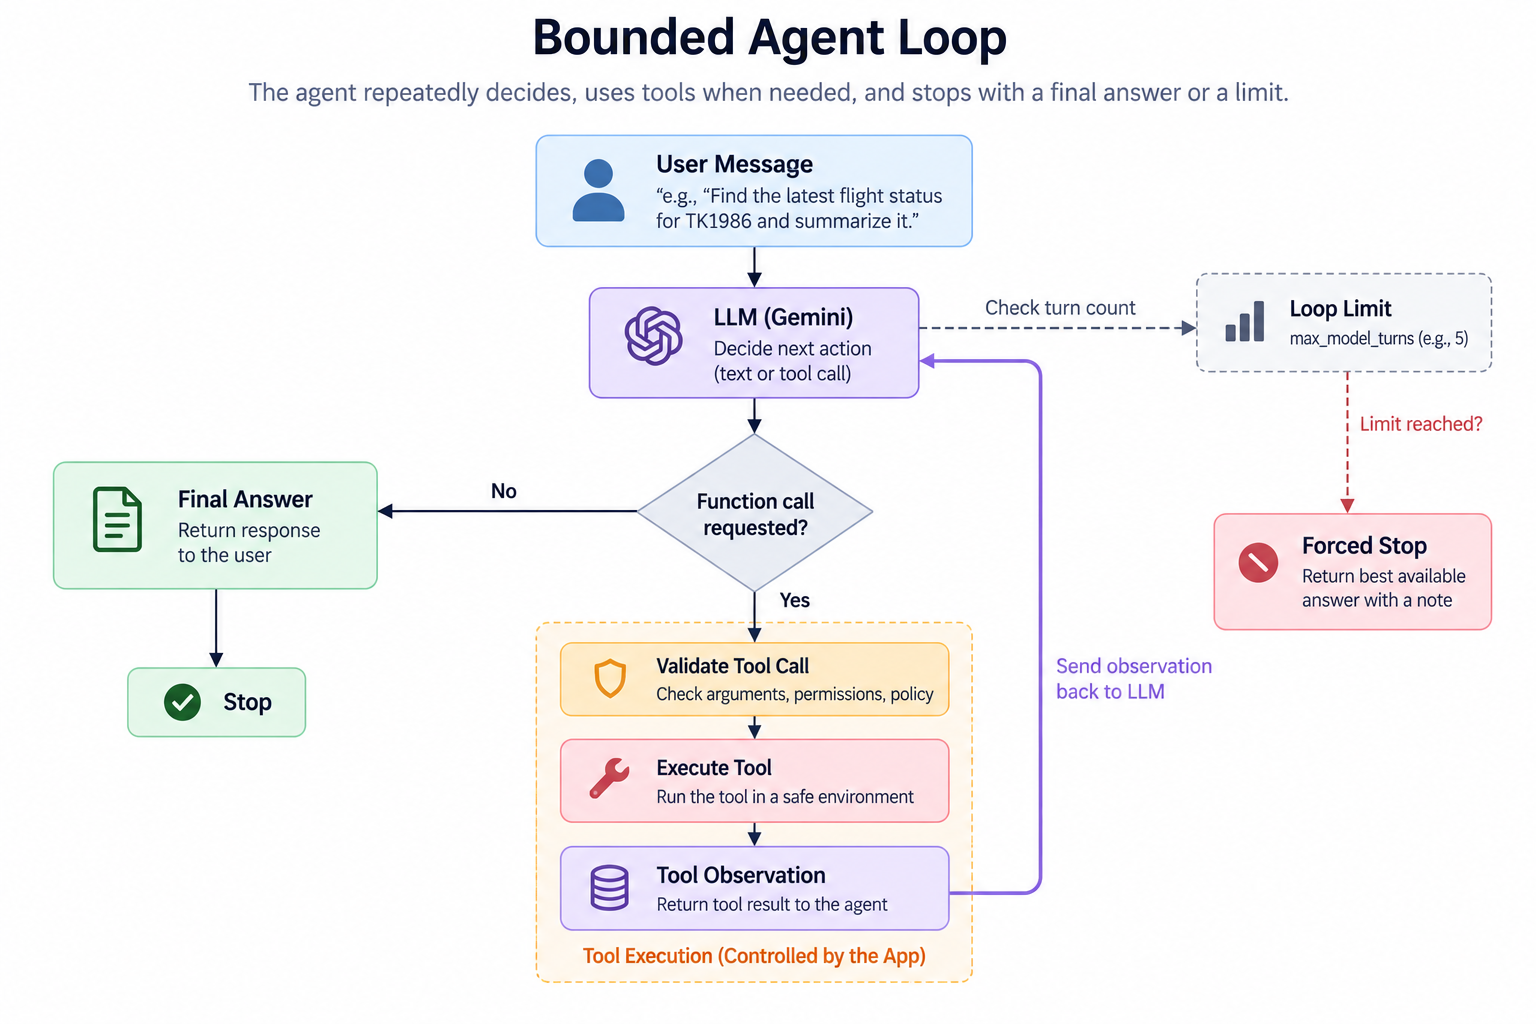

In [17]:
def make_json_safe(value: Any) -> Any:
    """Recursively convert values into JSON-serializable objects."""

    if isinstance(value, BaseException):
        return {
            "error": str(value),
            "error_type": type(value).__name__,
        }

    if isinstance(value, dict):
        return {
            str(key): make_json_safe(val)
            for key, val in value.items()
        }

    if isinstance(value, (list, tuple)):
        return [make_json_safe(item) for item in value]

    if value is None or isinstance(value, (str, int, float, bool)):
        return value

    # Defensive fallback for custom/non-JSON objects.
    return str(value)


def run_agent(
    user_message: str,
    *,
    max_model_turns: int = 6,
) -> AgentRun:
    if max_model_turns < 1:
        raise ValueError("max_model_turns must be at least 1")

    trace: list[dict[str, Any]] = [
        {"event": "user_message", "content": user_message}
    ]

    interaction = client.interactions.create(
        model=MODEL_NAME,
        input=user_message,
        tools=gemini_tools,
    )

    for turn_number in range(1, max_model_turns + 1):
        trace.append(
            {
                "event": "model_response",
                "turn": turn_number,
                "interaction_id": interaction.id,
                "step_types": [step.type for step in interaction.steps],
            }
        )

        function_calls = [
            step
            for step in interaction.steps
            if step.type == "function_call"
        ]

        if not function_calls:
            final_answer = interaction.output_text

            if final_answer:
                trace.append(
                    {
                        "event": "final_answer",
                        "content": final_answer,
                    }
                )

                return AgentRun(
                    status="completed",
                    answer=final_answer,
                    model_turns=turn_number,
                    trace=trace,
                    stop_reason="final_answer",
                )

            return AgentRun(
                status="failed",
                answer=None,
                model_turns=turn_number,
                trace=trace,
                stop_reason=(
                    "model_returned_neither_answer_nor_function_call"
                ),
            )

        function_results = []

        for function_call in function_calls:
            arguments = dict(function_call.arguments)

            trace.append(
                {
                    "event": "function_call",
                    "turn": turn_number,
                    "call_id": function_call.id,
                    "name": function_call.name,
                    "arguments": arguments,
                }
            )

            try:
                observation = registry.execute(
                    function_call.name,
                    arguments,
                )

            except Exception as exc:
                observation = {
                    "ok": False,
                    "error": str(exc),
                    "error_type": type(exc).__name__,
                }

            # Important:
            # registry.execute() may return a dict containing
            # exception objects rather than raising them.
            # Convert everything recursively to JSON-safe values.
            observation = make_json_safe(observation)

            trace.append(
                {
                    "event": "tool_observation",
                    "turn": turn_number,
                    "call_id": function_call.id,
                    "name": function_call.name,
                    "observation": observation,
                }
            )

            function_results.append(
                {
                    "type": "function_result",
                    "name": function_call.name,
                    "call_id": function_call.id,
                    "result": [
                        {
                            "type": "text",
                            "text": json.dumps(observation),
                        }
                    ],
                }
            )

        if turn_number == max_model_turns:
            break

        interaction = client.interactions.create(
            model=MODEL_NAME,
            previous_interaction_id=interaction.id,
            input=function_results,
            tools=gemini_tools,
        )

    trace.append(
        {
            "event": "run_stopped",
            "reason": "maximum_model_turns_reached",
        }
    )

    return AgentRun(
        status="stopped",
        answer=None,
        model_turns=max_model_turns,
        trace=trace,
        stop_reason="maximum_model_turns_reached",
    )

The loop does not retry API exceptions automatically. Network retry and backoff are separate operational concerns and should be added deliberately with bounded attempts. The current version focuses on agent control flow.

## 7. Test a direct answer

A complete agent must handle requests that do not require tools. Gemini should normally answer this general question directly, although the trace—not our expectation—is the source of truth.

In [11]:
direct_run = run_agent(
    "Explain in one sentence why an agent needs a stop condition."
)

print_trace(direct_run)

Status      : completed
Model turns : 2
Stop reason : final_answer
Answer      : An agent needs a stop condition to terminate its execution loop once its goal is reached or limits are exceeded, preventing infinite execution and uncontrolled resource consumption.

Trace:
01. {'event': 'user_message', 'content': 'Explain in one sentence why an agent needs a stop condition.'}
02. {'event': 'model_response', 'turn': 1, 'interaction_id': 'v1_ChdOQnEyYXFXd0t2LVJtdGtQa1BfR2dBSRIXTkJxMmFxV3dLdi1SbXRrUGtQX0dnQUk', 'step_types': ['thought', 'function_call']}
03. {'event': 'function_call', 'turn': 1, 'call_id': 'call_1176012', 'name': 'search_course_notes', 'arguments': {'query': 'stop condition'}}
04. {'event': 'tool_observation', 'turn': 1, 'call_id': 'call_1176012', 'name': 'search_course_notes', 'observation': {'success': True, 'result': [{'topic': 'agent', 'text': 'An agent places model-driven decisions inside a controlled loop with tools, state, and stop conditions.'}]}}
05. {'event': 'mode

## 8. Test one tool call

This request should produce one multiplication call followed by a final answer.

In [12]:
multiplication_run = run_agent(
    "Calculate 38 multiplied by 47 using the appropriate tool."
)

print_trace(multiplication_run)

Status      : completed
Model turns : 2
Stop reason : final_answer
Answer      : 38 multiplied by 47 is **1,786**.

Trace:
01. {'event': 'user_message', 'content': 'Calculate 38 multiplied by 47 using the appropriate tool.'}
02. {'event': 'model_response', 'turn': 1, 'interaction_id': 'v1_ChdFaHUyYXY2aE43Q3hxdHNQM2VyWDhRTRIXRWh1MmF2NmhON0N4cXRzUDNlclg4UU0', 'step_types': ['thought', 'function_call']}
03. {'event': 'function_call', 'turn': 1, 'call_id': 'call_1473497', 'name': 'multiply', 'arguments': {'second_number': 47, 'first_number': 38}}
04. {'event': 'tool_observation', 'turn': 1, 'call_id': 'call_1473497', 'name': 'multiply', 'observation': {'success': True, 'result': 1786.0}}
05. {'event': 'model_response', 'turn': 2, 'interaction_id': 'v1_ChdFaHUyYXY2aE43Q3hxdHNQM2VyWDhRTRIXRkJ1MmFwdkZQUC1SbXRrUGtQX0dnQUk', 'step_types': ['thought', 'model_output']}
06. {'event': 'final_answer', 'content': '38 multiplied by 47 is **1,786**.'}


## 9. Test multiple calls in one turn

Gemini may return the two independent calculations in parallel. It may also request them sequentially across turns. The loop supports both trajectories without special-case code.

In [13]:
multi_tool_run = run_agent(
    "Calculate both 8 multiplied by 7 and 12 multiplied by 9. "
    "Use the multiplication tool for both calculations."
)

print_trace(multi_tool_run)

Status      : completed
Model turns : 2
Stop reason : final_answer
Answer      : * **8 × 7** = 56
* **12 × 9** = 108

Trace:
01. {'event': 'user_message', 'content': 'Calculate both 8 multiplied by 7 and 12 multiplied by 9. Use the multiplication tool for both calculations.'}
02. {'event': 'model_response', 'turn': 1, 'interaction_id': 'v1_ChdGeHUyYXZ1WU9jNkdxdHNQdlluTzhRSRIXRnh1MmF2dVlPYzZHcXRzUHZZbk84UUk', 'step_types': ['thought', 'function_call', 'function_call']}
03. {'event': 'function_call', 'turn': 1, 'call_id': 'call_1978989', 'name': 'multiply', 'arguments': {'second_number': 7, 'first_number': 8}}
04. {'event': 'tool_observation', 'turn': 1, 'call_id': 'call_1978989', 'name': 'multiply', 'observation': {'success': True, 'result': 56.0}}
05. {'event': 'function_call', 'turn': 1, 'call_id': 'call_1978990', 'name': 'multiply', 'arguments': {'second_number': 9, 'first_number': 12}}
06. {'event': 'tool_observation', 'turn': 1, 'call_id': 'call_1978990', 'name': 'multiply', 'obser

Inspect the trace rather than checking only the answer. Two `function_call` events before the next `model_response` indicate parallel tool requests. Calls appearing on different turns indicate sequential execution.

## 10. Test a validation failure

The division schema rejects a zero denominator. The failure becomes an observation, allowing Gemini to explain that the requested calculation is undefined rather than causing the notebook to crash.

In [18]:
invalid_division_run = run_agent(
    "Use the division tool to calculate 12 divided by 0. If the tool "
    "rejects the request, explain the problem rather than inventing a result."
)

print_trace(invalid_division_run)

Status      : completed
Model turns : 2
Stop reason : final_answer
Answer      : The division tool rejected the request with the error: **"denominator must not be zero."**

### Explanation
In mathematics, division by zero is undefined. Division asks the question: *"What number multiplied by the denominator equals the numerator?"* In this case, there is no number that can be multiplied by $0$ to equal $12$ ($0 \times x = 0$ for all real numbers $x$). Consequently, the operation cannot be performed.

Trace:
01. {'event': 'user_message', 'content': 'Use the division tool to calculate 12 divided by 0. If the tool rejects the request, explain the problem rather than inventing a result.'}
02. {'event': 'model_response', 'turn': 1, 'interaction_id': 'v1_Chc1QnkyYXZmd0VPV2txdHNQbTRQUjRBRRIXNUJ5MmF2ZndFT1drcXRzUG00UFI0QUU', 'step_types': ['thought', 'function_call']}
03. {'event': 'function_call', 'turn': 1, 'call_id': 'call_547758', 'name': 'divide', 'arguments': {'numerator': 12, 'denominator

## 11. Test retrieval followed by another tool

This prompt requires course-specific retrieval and arithmetic. The order is not hard-coded; Gemini chooses the trajectory from the available tools and observations.

In [15]:
composed_run = run_agent(
    "According to the local notes, define an execution trace. Then calculate "
    "the number of letters in the word 'trace' multiplied by 9. Use tools "
    "where appropriate."
)

print_trace(composed_run)

Status      : completed
Model turns : 2
Stop reason : final_answer
Answer      : According to the local notes, an **execution trace** records model calls, requested actions, tool results, failures, and termination reasons.

The word **trace** has 5 letters. Multiplying by 9:
$$5 \times 9 = 45$$

Trace:
01. {'event': 'user_message', 'content': "According to the local notes, define an execution trace. Then calculate the number of letters in the word 'trace' multiplied by 9. Use tools where appropriate."}
02. {'event': 'model_response', 'turn': 1, 'interaction_id': 'v1_ChdRQnkyYXBMakM0bUFtdGtQX0t5TzJBNBIXUUJ5MmFwTGpDNG1BbXRrUF9LeU8yQTQ', 'step_types': ['thought', 'function_call', 'function_call']}
03. {'event': 'function_call', 'turn': 1, 'call_id': 'call_2571869', 'name': 'search_course_notes', 'arguments': {'query': 'execution trace'}}
04. {'event': 'tool_observation', 'turn': 1, 'call_id': 'call_2571869', 'name': 'search_course_notes', 'observation': {'success': True, 'result': [{'topi

The prompt asks the model to infer that `trace` has five letters. Our current tools do not include a character counter, so the model may count directly and call only multiplication after retrieval. Later evaluation will help us decide whether such behavior is acceptable for the intended application.

## 12. Stop-condition behavior

The loop checks three terminal situations:

- **Completed:** Gemini returns a final textual answer.
- **Failed:** Gemini returns neither a final answer nor a function call.
- **Stopped:** the maximum model-turn budget is reached.

A maximum step or turn count is a safety boundary, not merely a performance optimization. It prevents accidental loops from consuming unbounded time and API quota.

## 13. Exercise: summarize a run

Write a function named `summarize_run(run)` that returns a dictionary containing:

- `status`;
- `model_turns`;
- number of `function_call` events;
- ordered list of tool names;
- number of failed tool observations; and
- `stop_reason`.

Test it with `multi_tool_run` and `invalid_division_run`.

In [16]:
def summarize_run(run: AgentRun) -> dict[str, Any]:
    # Extract summary metrics from run.trace.
    raise NotImplementedError

<details>
<summary><strong>Reveal one possible solution</strong></summary>

```python
def summarize_run(run: AgentRun) -> dict[str, Any]:
    function_calls = [
        event for event in run.trace
        if event["event"] == "function_call"
    ]
    observations = [
        event for event in run.trace
        if event["event"] == "tool_observation"
    ]
    failed_observations = [
        event for event in observations
        if not event["observation"]["success"]
    ]

    return {
        "status": run.status,
        "model_turns": run.model_turns,
        "function_call_count": len(function_calls),
        "tool_names": [event["name"] for event in function_calls],
        "failed_tool_observations": len(failed_observations),
        "stop_reason": run.stop_reason,
    }
```

</details>

## Notebook summary

We converted a single function-calling exchange into a bounded agent loop. The runtime supports direct answers, sequential and parallel tool requests, Pydantic validation, structured error observations, execution traces, and explicit termination states.

The implementation is still intentionally small. It does not yet provide durable conversation memory, checkpointing, human approval, provider-independent adapters, or systematic evaluation. The next notebook will focus on agent state and memory before we introduce LangGraph as a framework for managing these transitions.

### Reference

- [Gemini API function calling](https://ai.google.dev/gemini-api/docs/function-calling)